  transaction_id user_id  age gender  daily_screen_time_hours  \
0       TXN00001  U00001   21   Male                     3.23   
1       TXN00002  U00002   24  Other                     5.09   
2       TXN00003  U00003   31  Other                     6.06   
3       TXN00004  U00004   32  Other                     7.83   
4       TXN00005  U00005   25   Male                     9.96   

   social_media_hours  gaming_hours  work_study_hours  sleep_hours  \
0                2.01          0.89              4.55         7.55   
1                3.81          2.24              4.44         7.66   
2                1.36          3.83              2.35         4.92   
3                5.85          1.51              3.54         8.23   
4                5.92          3.42              5.27         6.21   

   notifications_per_day  app_opens_per_day  weekend_screen_time stress_level  \
0                    248                154                 3.95       Medium   
1                    127  

C:\Users\LENOVO LOQ\AppData\Local\Temp\ipykernel_26152\3996985957.py:100: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X.select_dtypes(include='object').columns:



HASIL XGBOOST

Accuracy: 0.5587135377711294

ROC AUC: 0.7675251402609504

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.78      0.86      0.82       275
           1       0.49      0.49      0.49       575
           2       0.50      0.47      0.49       487

    accuracy                           0.56      1337
   macro avg       0.59      0.61      0.60      1337
weighted avg       0.55      0.56      0.56      1337



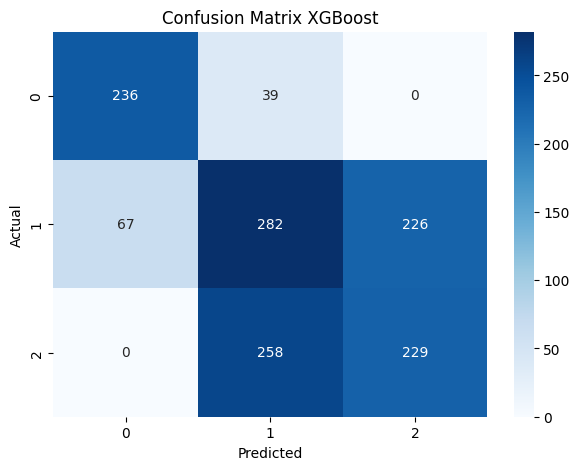


TOP FEATURE IMPORTANCE
                    Feature  Importance
3        social_media_hours    0.281942
2   daily_screen_time_hours    0.258297
9       weekend_screen_time    0.087317
6               sleep_hours    0.042595
11     academic_work_impact    0.042476
4              gaming_hours    0.041878
7     notifications_per_day    0.041803
8         app_opens_per_day    0.041477
0                       age    0.041317
5          work_study_hours    0.041226


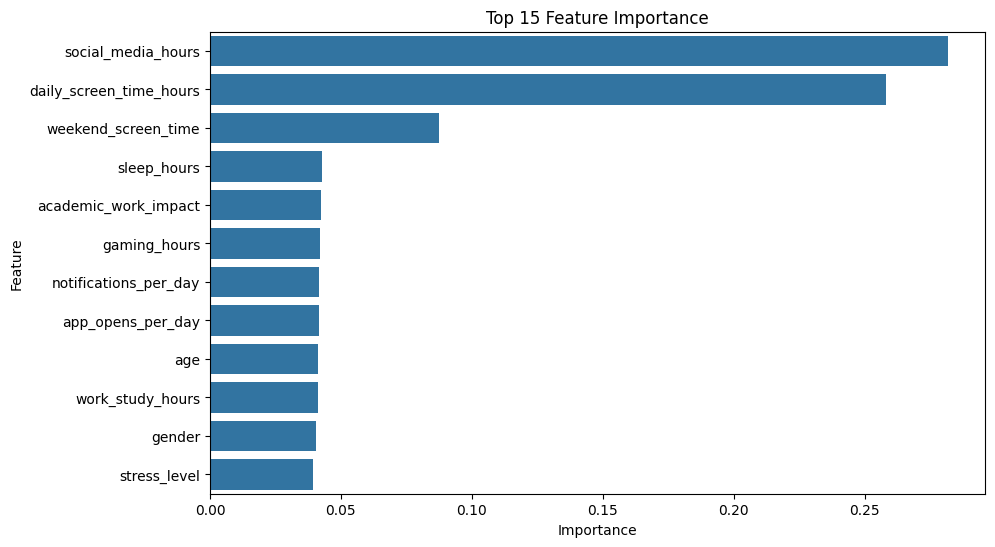


SAMPLE PREDICTION
[2 1 2 0 0]

ACTUAL LABEL
[1 1 2 0 0]

MODEL BERHASIL DISIMPAN


In [2]:
# =========================================================
# XGBOOST - SMARTPHONE ADDICTION DETECTION
# MULTICLASS CLASSIFICATION
# =========================================================

# =========================
# 1. IMPORT LIBRARY
# =========================

import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Evaluasi
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# Model
from xgboost import XGBClassifier


# =========================
# 2. LOAD DATASET
# =========================

df = pd.read_csv(r"E:\Python - Project\phone-addiction-detection\Data\Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")

print(df.head())

print("\nSHAPE DATASET:", df.shape)


# =========================
# 3. DATA UNDERSTANDING
# =========================

print("\nINFO DATASET")
print(df.info())

print("\nMISSING VALUE")
print(df.isnull().sum())

print("\nNAMA KOLOM")
print(df.columns)


# =========================
# 4. TARGET & DROP COLUMN
# =========================

TARGET = 'addiction_level'

drop_cols = [
    'transaction_id',
    'user_id',
    'addicted_label'   # leakage
]

# Hapus target yang kosong
df = df.dropna(subset=[TARGET])

# Pisahkan feature dan target
X = df.drop(columns=[TARGET] + drop_cols)

y = df[TARGET]


# =========================
# 5. ENCODE TARGET
# =========================

target_encoder = LabelEncoder()

y = target_encoder.fit_transform(
    y.astype(str)
)

print("\nKELAS TARGET:")
print(np.unique(y))


# =========================
# 6. ENCODE FEATURE
# =========================

label_encoders = {}

for col in X.select_dtypes(include='object').columns:

    le = LabelEncoder()

    X[col] = le.fit_transform(
        X[col].astype(str)
    )

    label_encoders[col] = le


# =========================
# 7. HANDLE MISSING VALUE
# =========================

imputer = SimpleImputer(
    strategy='most_frequent'
)

X = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

# Bersihkan inf
X = X.replace([np.inf, -np.inf], np.nan)

X = X.fillna(0)


# =========================
# 8. CEK FINAL
# =========================

print("\nTOTAL NaN X:",
      X.isnull().sum().sum())

print("TOTAL NaN y:",
      pd.Series(y).isnull().sum())

print("\nSHAPE X:", X.shape)
print("SHAPE y:", y.shape)


# =========================
# 9. TRAIN TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("\nTRAIN SHAPE:", X_train.shape)

print("TEST SHAPE:", X_test.shape)


# =========================
# 10. STANDARD SCALER
# =========================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


# =========================
# 11. MODEL XGBOOST
# =========================

xgb_model = XGBClassifier(

    objective='multi:softprob',

    num_class=len(np.unique(y)),

    n_estimators=500,

    max_depth=8,

    learning_rate=0.03,

    subsample=0.8,

    colsample_bytree=0.8,

    gamma=1,

    min_child_weight=3,

    reg_alpha=0.5,

    reg_lambda=1,

    eval_metric='mlogloss',

    random_state=42
)

xgb_model.fit(
    X_train_scaled,
    y_train
)


# =========================
# 12. PREDIKSI
# =========================

y_pred = xgb_model.predict(
    X_test_scaled
)

y_prob = xgb_model.predict_proba(
    X_test_scaled
)


# =========================
# 13. EVALUASI
# =========================

print("\n========================")
print("HASIL XGBOOST")
print("========================")

print(
    "\nAccuracy:",
    accuracy_score(y_test, y_pred)
)

print(
    "\nROC AUC:",
    roc_auc_score(
        y_test,
        y_prob,
        multi_class='ovr'
    )
)

print("\nCLASSIFICATION REPORT")

print(
    classification_report(
        y_test,
        y_pred
    )
)


# =========================
# 14. CONFUSION MATRIX
# =========================

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix XGBoost")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()


# =========================
# 15. FEATURE IMPORTANCE
# =========================

importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance': xgb_model.feature_importances_

})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nTOP FEATURE IMPORTANCE")

print(importance.head(10))


plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(15),
    x='Importance',
    y='Feature'
)

plt.title("Top 15 Feature Importance")

plt.show()


# =========================
# 16. PREDIKSI SAMPLE
# =========================

sample_prediction = xgb_model.predict(
    X_test_scaled[:5]
)

print("\nSAMPLE PREDICTION")

print(sample_prediction)

print("\nACTUAL LABEL")

print(y_test[:5])


# =========================
# 17. SAVE MODEL
# =========================

import joblib

joblib.dump(
    xgb_model,
    'xgboost_addiction_model.pkl'
)

print("\nMODEL BERHASIL DISIMPAN")